<a href="https://colab.research.google.com/github/abeeraz379/california_housing/blob/main/california_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# california_housing
- By : ABeer AL-Zebda | Ml Engineer
- Data Link : https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_california_housing.html

## Import libraries

In [1]:
import numpy as np  # Import NumPy for numerical operations and arrays
import seaborn as sns
import matplotlib.pyplot as plt  # Import Matplotlib for creating graphs and visualizations

from sklearn.linear_model import LinearRegression, Ridge  # Import Linear Regression and Ridge Regression models

from sklearn.preprocessing import StandardScaler, PolynomialFeatures  # Import tools for feature scaling and polynomial features

from sklearn.model_selection import train_test_split  # Import function to split data into training, validation, and test sets

from sklearn.metrics import mean_squared_error  # Import function to calculate Mean Squared Error

import tensorflow as tf  # Import TensorFlow for building neural networks

from tensorflow.keras.models import Sequential  # Import Sequential model to build layers step by step

from tensorflow.keras.layers import Dense  # Import Dense layer, the basic fully connected neural network layer

from tensorflow.keras.activations import relu, linear  # Import ReLU and linear activation functions

from tensorflow.keras.optimizers import Adam  # Import Adam optimizer for training neural networks

import logging  # Import logging library to control warning and error messages

logging.getLogger("tensorflow").setLevel(logging.ERROR)  # Show only TensorFlow errors and hide warning messages

## Load and inspect data

In [2]:

from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

df = data.frame

print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [3]:
data.target

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
df.isna().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


In [7]:
df.duplicated().sum()

np.int64(0)

## Exploratory Visualizations

Text(0, 0.5, 'MedHouseVal')

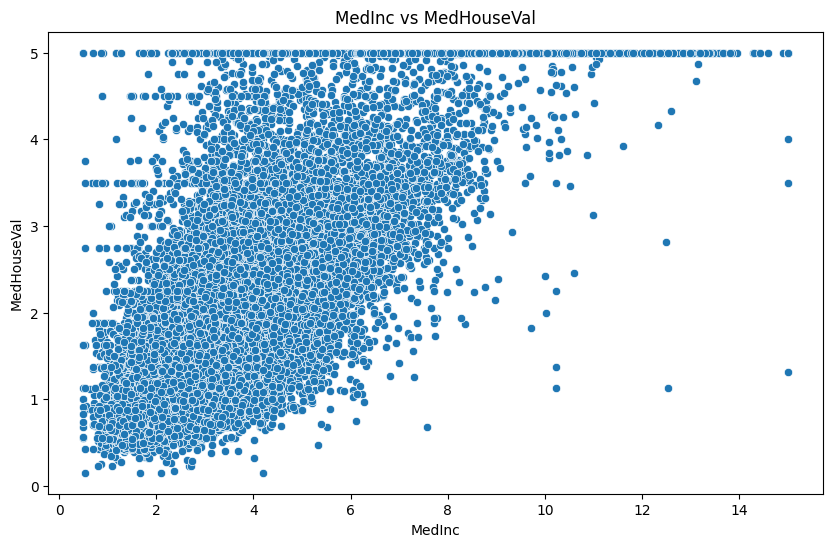

In [8]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='MedInc',y='MedHouseVal')
ax.set_title('MedInc vs MedHouseVal')
ax.set_xlabel('MedInc')
ax.set_ylabel('MedHouseVal')

It's a positive correlation between Medium House Value (target) and Medium Income

Text(0, 0.5, 'MedHouseVal')

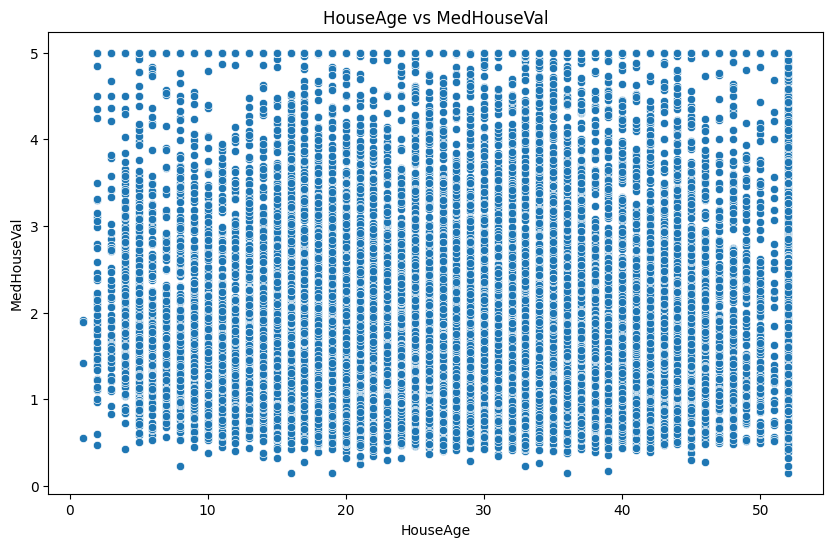

In [9]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='HouseAge',y='MedHouseVal')
ax.set_title('HouseAge vs MedHouseVal')
ax.set_xlabel('HouseAge')
ax.set_ylabel('MedHouseVal')

There are no clear relationship

Text(0, 0.5, 'MedHouseVal')

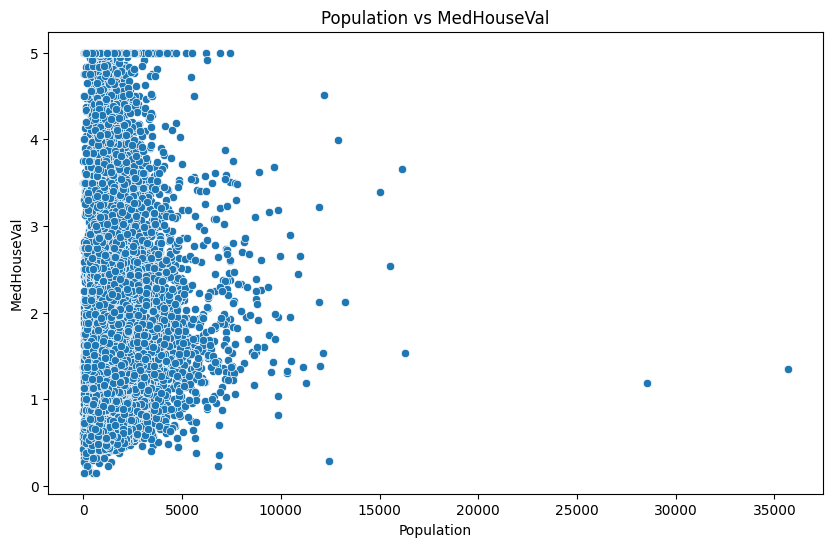

In [10]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='Population',y='MedHouseVal')
ax.set_title('Population vs MedHouseVal')
ax.set_xlabel('Population')
ax.set_ylabel('MedHouseVal')

most of the population is between 0 and 10000

## Preprocessing

In [11]:
X = df.drop(columns=["MedHouseVal"])
y = df['MedHouseVal']

In [12]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Build Neural network

In [14]:

model = Sequential([
    Dense(64, activation='relu', input_shape=(8,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1)
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:

model.compile(
    loss='mse',
    optimizer='adam',
    metrics=[tf.keras.metrics.R2Score()]
)


## Train Model

In [16]:

history = model.fit(X_train, y_train, epochs=40, validation_data=(X_test, y_test), batch_size=32)

Epoch 1/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.8097 - r2_score: 0.3943 - val_loss: 0.4123 - val_r2_score: 0.6854
Epoch 2/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3761 - r2_score: 0.7187 - val_loss: 0.3738 - val_r2_score: 0.7148
Epoch 3/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3515 - r2_score: 0.7371 - val_loss: 0.3554 - val_r2_score: 0.7288
Epoch 4/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3302 - r2_score: 0.7530 - val_loss: 0.3289 - val_r2_score: 0.7490
Epoch 5/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3185 - r2_score: 0.7617 - val_loss: 0.3294 - val_r2_score: 0.7487
Epoch 6/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3122 - r2_score: 0.7664 - val_loss: 0.3203 - val_r2_score: 0.7556
Epoch 7/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3037 - r2_score: 0.7728 - val_loss: 0.3195 - val_r2_score: 0.7562
Epoch 8/40
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3014 - r2_score: 0.7745 - val_loss: 0.3040

In [17]:

pred = model.predict(X_test)

print("Predicted:", pred[:10].flatten())
print("True:", y_test[:10].values)


129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Predicted: [0.55926853 0.8568343  5.132153   2.4986198  2.4916217  1.753367
 2.4803658  1.6616136  2.200928   4.5421267 ]
True: [0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]
